# Experiment 3 data audit

## tl;dr

공식 Figshare experiment 3 원자료에서 시간 일치 24시간 주 코호트 94개와
pooled-control 민감도 코호트 97개를 확인했다. 이 노트북은 원자료 감사 로그와
추적 가능한 표를 다시 읽어 핵심 불변조건을 검증한다.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, display

root = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "pyproject.toml").exists() and (path / "cell_count_matrix.csv").exists()
)


In [2]:
core = json.loads((root / "results/logs/core_audit_summary.json").read_text())
counts = pd.read_csv(root / "cell_count_matrix.csv")

audit_summary = pd.DataFrame({
    "metric": [
        "genes", "normal cells: DMSO 6h", "normal cells: DMSO 24h",
        "normal cells: trametinib 24h", "strict primary lines", "pooled sensitivity lines"
    ],
    "value": [
        32_738,
        core["archives"]["dmso_6h"]["cells_normal"],
        core["archives"]["dmso_24h"]["cells_normal"],
        core["archives"]["trametinib_24h"]["cells_normal"],
        core["primary_strict_eligible_lines"],
        core["reproduction_pooled_eligible_lines"],
    ],
})
display(audit_summary)
assert core["primary_strict_eligible_lines"] == 94
assert core["reproduction_pooled_eligible_lines"] == 97
assert counts["cell_line"].is_unique


,metric,value
0,genes,32738
1,normal cells: DMSO 6h,8398
2,normal cells: DMSO 24h,6075
3,normal cells: trametinib 24h,10657
4,strict primary lines,94
5,pooled sensitivity lines,97


## Context & Methods

### Key Assumptions

- 분석 단위는 세포가 아니라 cell line이다.
- `cell_quality == "normal"`만 포함한다.
- 주 분석은 `DMSO_24hr_expt3` 대 `Trametinib_24hr_expt3`다.
- 각 조건에서 정상 세포 20개 이상인 세포주만 주 코호트에 포함한다.
- DMSO 6h+24h pooling은 주 분석이 아니라 민감도 분석이다.

## Data

In [3]:
manifest = pd.read_csv(root / "data_manifest.csv")
display(manifest[["source_role", "bytes", "sha256", "status"]])
display(counts.head(10))


,source_role,bytes,sha256,status
0,preprocessed_anndata,1459410830,94a7240047b9ce6822dc2aa1e7a66c1fd8b00be842e5a9...,downloaded_probe_complete
1,figshare_readme,5515,003584fbb04c8493bdfcf84b6016929095563d6ec25890...,checksum_verified
2,supplementary_tables,87927,fb51fdd28f0d0f09767c1add5407a534f852fb3f670be2...,checksum_verified
3,core_dmso_6h,108722978,4d18e9729623a6fae995e69a055085782191e85b4097e1...,checksum_verified
4,core_dmso_24h,131222789,1efb688c8b1c1633f0947ae42e4ac8df6a4b5faec5e596...,checksum_verified
5,core_trametinib_24h,128307482,058439c54f5863311ae196d992b4e4375ca23c832eaf7b...,checksum_verified
6,cell_line_features,3097885,58c65f74974be33311c7d06409d9121d1a5fc1630bf49a...,checksum_verified


,cell_line,depmap_id,dmso_6h_normal,dmso_24h_normal,trametinib_24h_normal,dmso_pooled_normal,primary_strict_eligible,reproduction_pooled_eligible
0,22RV1_PROSTATE,ACH-000956,101,43,69,144,True,True
1,42MGBA_CENTRAL_NERVOUS_SYSTEM,ACH-000323,112,77,167,189,True,True
2,769P_KIDNEY,ACH-000411,140,110,197,250,True,True
3,786O_KIDNEY,ACH-000649,135,108,254,243,True,True
4,8505C_THYROID,ACH-001307,104,91,116,195,True,True
5,A2780_OVARY,ACH-000657,118,182,206,300,True,True
6,A375_SKIN,ACH-000219,75,102,135,177,True,True
7,ACCMESO1_PLEURA,ACH-000086,129,97,183,226,True,True
8,AGS_STOMACH,ACH-000880,118,101,125,219,True,True
9,BEN_LUNG,ACH-000603,86,74,163,160,True,True


## Results

,normal_cells
dmso_6h_normal,8398
dmso_24h_normal,6075
trametinib_24h_normal,10657


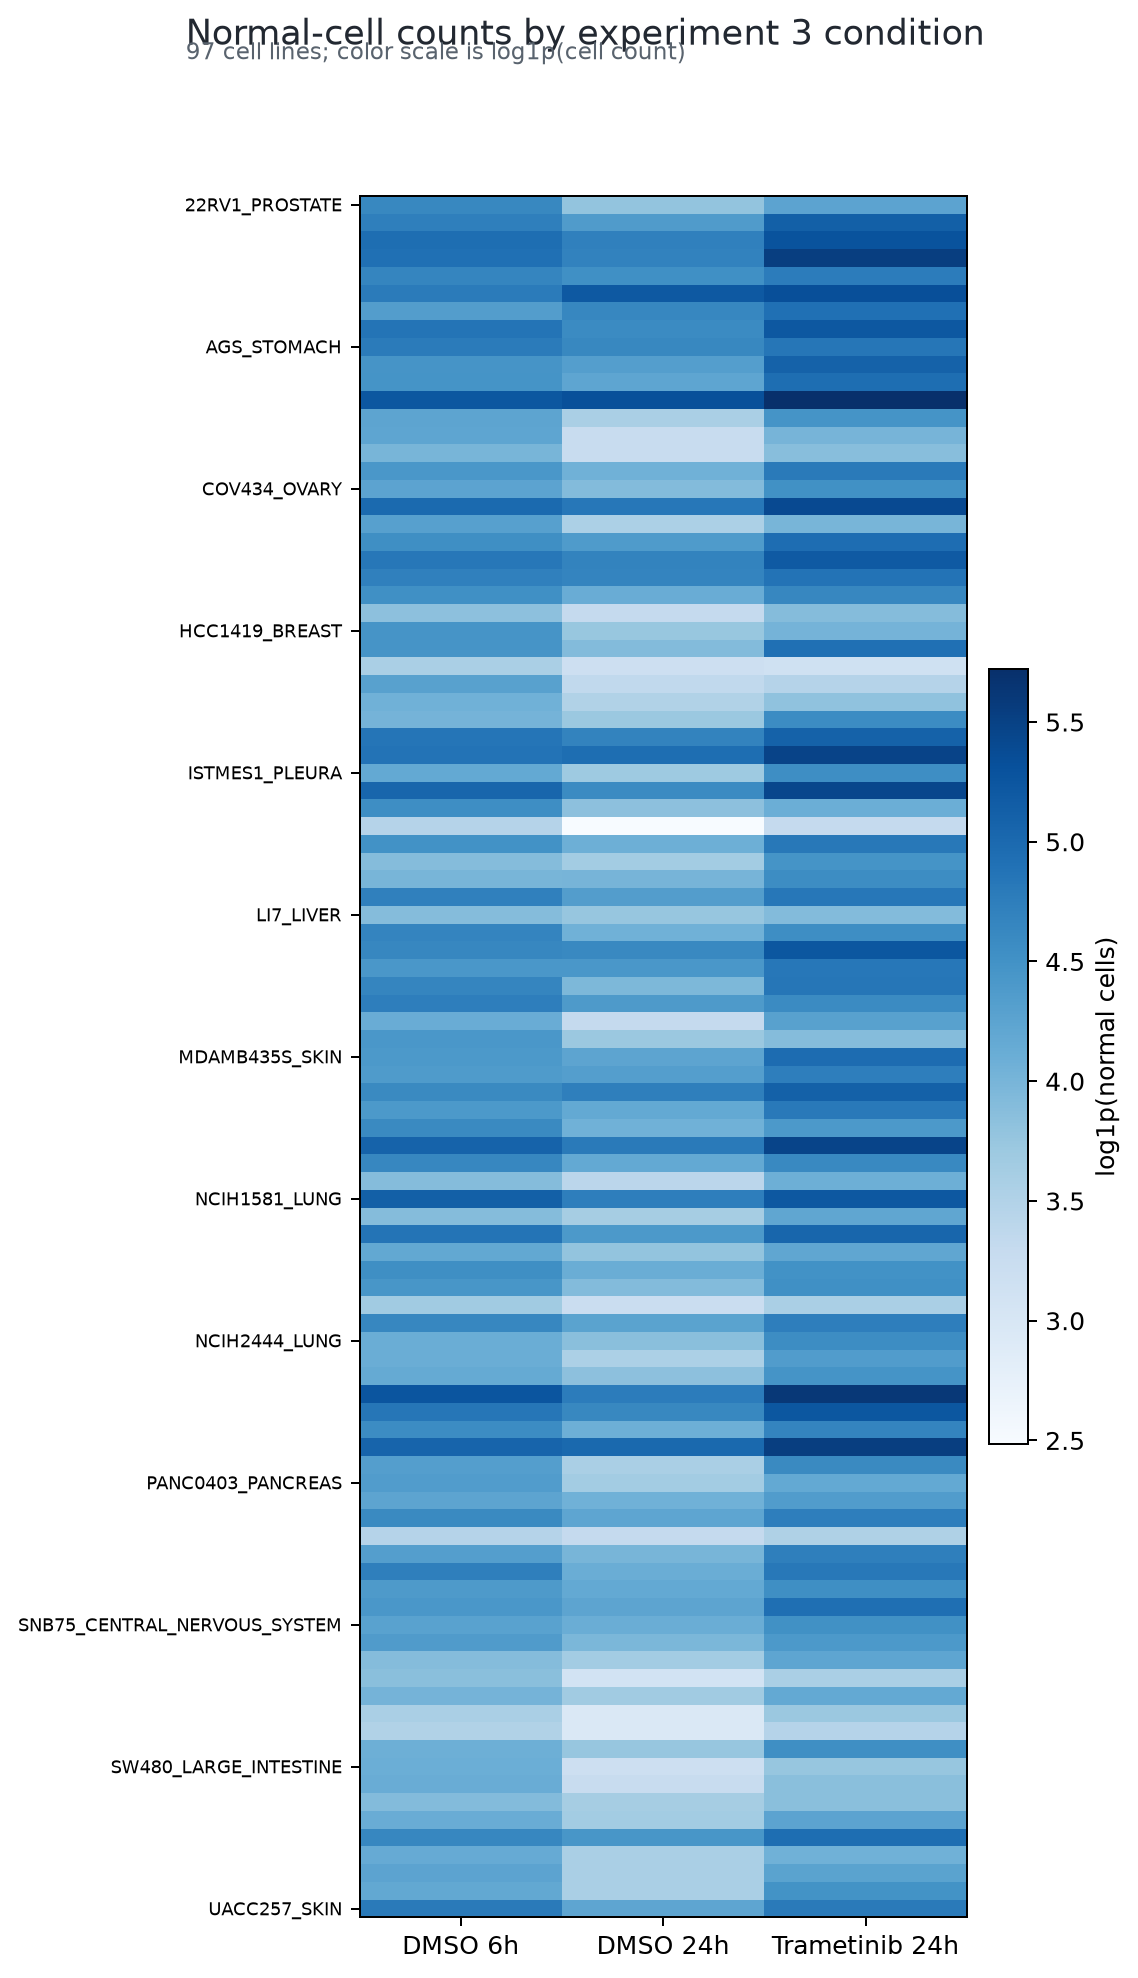

In [4]:
condition_totals = counts[[
    "dmso_6h_normal", "dmso_24h_normal", "trametinib_24h_normal"
]].sum().rename("normal_cells").to_frame()
display(condition_totals)
display(Image(filename=str(root / "results/figures/cell_count_heatmap.png")))


## Takeaways

- 단순 통합 AnnData 필터 대신 experiment 3 원자료를 직접 사용해야 한다.
- 24시간 time-matched 주 코호트는 94개 세포주다.
- 저자 방식의 pooled-control 재현 코호트는 97개지만 별도 민감도 분석으로 유지한다.
- 원 Matrix Market 행렬은 32,738 genes × cells의 non-negative integer raw count다.